In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [3]:
#Data preparation
heart = pd.read_excel(r"C:\Users\Lenovo\Downloads\Decision Tree\Decision Tree\heart_disease.xlsx",sheet_name='Heart_disease')
heart

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal,num
0,63,Male,typical angina,145,233,True,lv hypertrophy,150,False,2.3,downsloping,fixed defect,0
1,41,Male,atypical angina,135,203,False,normal,132,False,0.0,flat,fixed defect,0
2,57,Male,asymptomatic,140,192,False,normal,148,False,0.4,flat,fixed defect,0
3,52,Male,typical angina,118,186,False,lv hypertrophy,190,False,0.0,flat,fixed defect,0
4,57,Male,asymptomatic,110,201,False,normal,126,True,1.5,flat,fixed defect,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
903,53,Male,asymptomatic,125,0,False,normal,120,False,1.5,upsloping,reversable defect,4
904,62,Male,asymptomatic,166,170,False,st-t abnormality,120,True,3.0,flat,reversable defect,4
905,56,Male,non-anginal,170,0,False,lv hypertrophy,123,True,2.5,downsloping,normal,4
906,56,Male,non-anginal,144,208,True,st-t abnormality,105,TURE,NaN,downsloping,fixed defect,4


In [5]:
#Details about the dataset:

# age: The age of the patient in years.
# sex: The gender of the patient.
#  -1 = male
# -0 = female
# cp (chest pain type): Describes the type of chest pain experienced by the patient.
#  -0 = Typical angina (chest pain related to decreased blood supply to the heart)
# - 1 = Atypical angina (chest pain not related to heart)
#  -2 = Non-anginal pain (chest pain not related to the heart)
#  -3 = Asymptomatic (no chest pain)
# trestbps (resting blood pressure): The patient’s resting blood pressure (in mm Hg) upon hospital admission.
# chol (serum cholesterol): The patient’s serum cholesterol level in mg/dL.
# fbs (fasting blood sugar): Indicates whether the patient's fasting blood sugar is higher than 120 mg/dL.
#  -1 = True
#  -0 = False
# restecg (resting electrocardiographic results): The results of the patient’s resting electrocardiogram.
#  -0 = Normal
#  -1 = Having ST-T wave abnormality (T wave inversions and/or ST elevation or depression of > 0.05 mV)
#  -2 = Showing probable or definite left ventricular hypertrophy by Estes' criteria
# thalch (maximum heart rate achieved): The maximum heart rate achieved during the stress test.
# exang (exercise-induced angina): Indicates whether the patient experiences angina (chest pain) during exercise.
#  -1 = Yes
#  -0 = No
# oldpeak: ST depression induced by exercise relative to rest, which can indicate the severity of heart disease.
# slope (slope of the peak exercise ST segment): Describes the slope of the peak exercise ST segment.
#  -0 = Upsloping (better heart condition)
#  -1 = Flat (indicative of possible heart disease)
#  -2 = Downsloping (worse heart condition)
# thal (thalassemia): Refers to a blood disorder, often a marker used in the dataset.
#  -1 = Fixed defect (no blood flow in some part of the heart)
#  -2 = Normal
#  -3 = Reversible defect (a blood flow issue that can be fixed)
# num (target variable): The diagnosis of heart disease, often represented as an integer.
#  -0 = No heart disease
#  -1, 2, 3, 4 = Various levels of heart disease severity, with 1 being mild and 4 being the most severe.

In [7]:
#EDA
heart.shape,heart.columns

((908, 13),
 Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalch',
        'exang', 'oldpeak', 'slope', 'thal', 'num'],
       dtype='object'))

In [9]:
heart.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 908 entries, 0 to 907
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       908 non-null    int64  
 1   sex       908 non-null    object 
 2   cp        908 non-null    object 
 3   trestbps  908 non-null    int64  
 4   chol      908 non-null    int64  
 5   fbs       908 non-null    bool   
 6   restecg   908 non-null    object 
 7   thalch    908 non-null    int64  
 8   exang     908 non-null    object 
 9   oldpeak   846 non-null    float64
 10  slope     908 non-null    object 
 11  thal      908 non-null    object 
 12  num       908 non-null    int64  
dtypes: bool(1), float64(1), int64(5), object(6)
memory usage: 86.1+ KB


In [11]:
heart.isna().mean()*100
#there are null values only in oldpeak column

age         0.000000
sex         0.000000
cp          0.000000
trestbps    0.000000
chol        0.000000
fbs         0.000000
restecg     0.000000
thalch      0.000000
exang       0.000000
oldpeak     6.828194
slope       0.000000
thal        0.000000
num         0.000000
dtype: float64

In [13]:
#null values in oldpeak column is replaced with mean value
heart['oldpeak'] = heart['oldpeak'].fillna(heart['oldpeak'].mean())
heart.isna().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalch      0
exang       0
oldpeak     0
slope       0
thal        0
num         0
dtype: int64

In [15]:
heart[heart.duplicated()]

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal,num
765,58,Male,non-anginal,150,219,False,st-t abnormality,118,True,0.0,downsloping,normal,2


In [17]:
heart[(heart['age']==58) & (heart['sex']== 'Male') & (heart['cp']== 'non-anginal') & (heart['trestbps']== 150) & (heart['chol']== 219)]
#both 764 and 765 columns contains same values,so duplicated value needs to be deleted

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal,num
764,58,Male,non-anginal,150,219,False,st-t abnormality,118,True,0.0,downsloping,normal,2
765,58,Male,non-anginal,150,219,False,st-t abnormality,118,True,0.0,downsloping,normal,2


In [19]:
heart = heart.drop_duplicates()
heart.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal,num
0,63,Male,typical angina,145,233,True,lv hypertrophy,150,False,2.3,downsloping,fixed defect,0
1,41,Male,atypical angina,135,203,False,normal,132,False,0.0,flat,fixed defect,0
2,57,Male,asymptomatic,140,192,False,normal,148,False,0.4,flat,fixed defect,0
3,52,Male,typical angina,118,186,False,lv hypertrophy,190,False,0.0,flat,fixed defect,0
4,57,Male,asymptomatic,110,201,False,normal,126,True,1.5,flat,fixed defect,0


In [21]:
heart.describe()

,age,trestbps,chol,thalch,oldpeak,num
count,907.000000,907.000000,907.000000,907.000000,907.000000,907.000000
mean,53.787211,133.412348,201.465270,135.976847,0.892236,1.007718
std,9.162016,20.405432,112.158285,26.813075,1.055993,1.144594
min,29.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.500000,120.000000,176.500000,118.000000,0.000000,0.000000
50%,54.000000,130.000000,224.000000,138.000000,0.800000,1.000000
75%,60.000000,144.000000,270.000000,156.000000,1.500000,2.000000
max,77.000000,200.000000,603.000000,202.000000,6.200000,4.000000


Creating boxplot for column: age


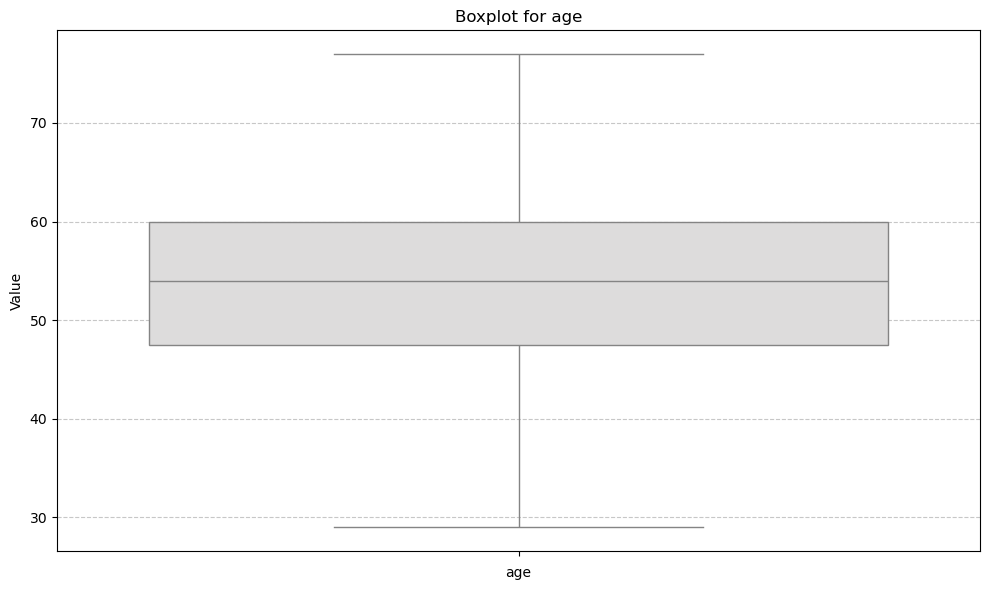

Creating boxplot for column: trestbps


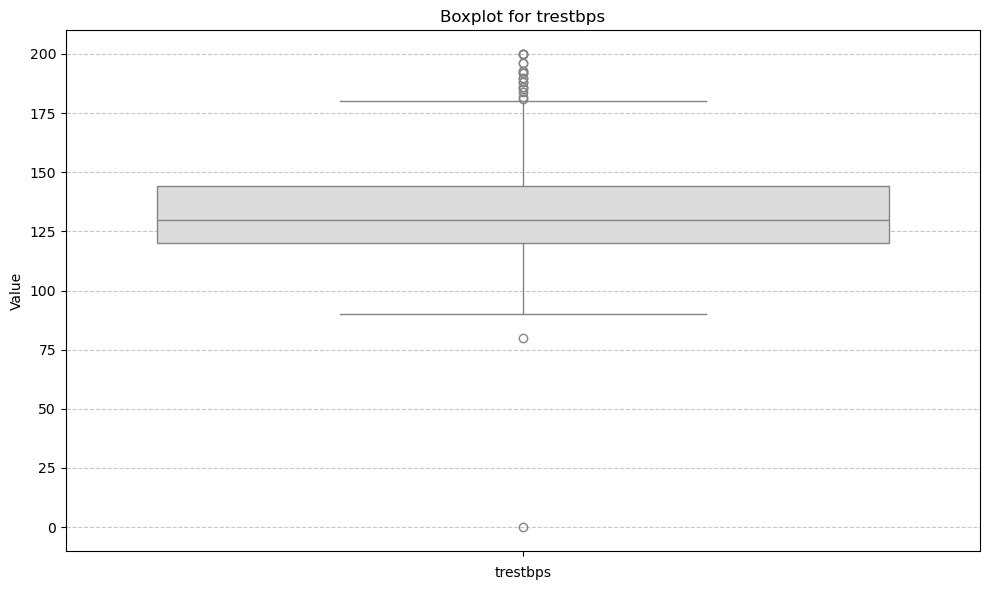

Creating boxplot for column: chol


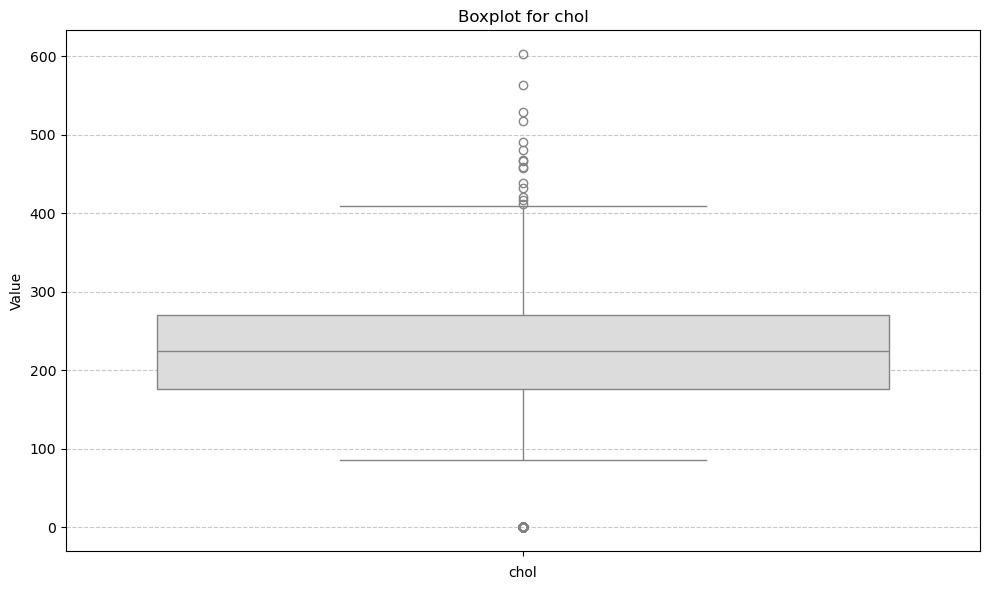

Creating boxplot for column: thalch


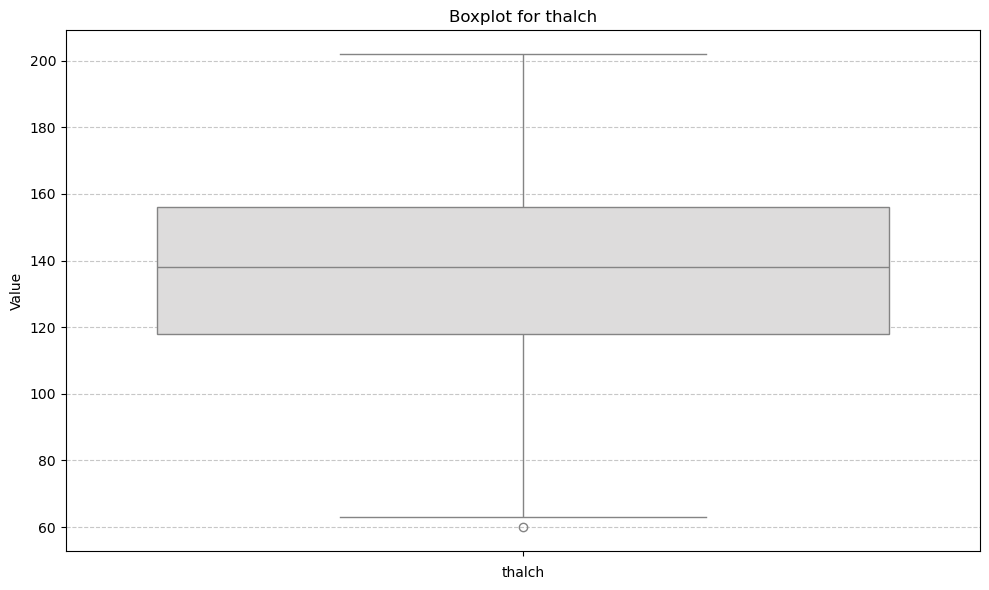

Creating boxplot for column: oldpeak


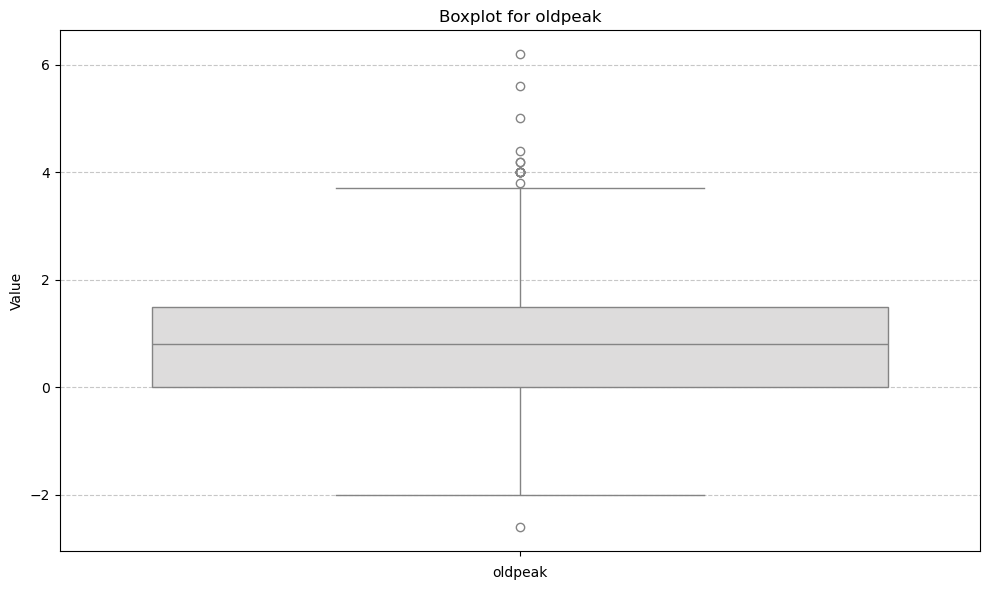

Creating boxplot for column: num


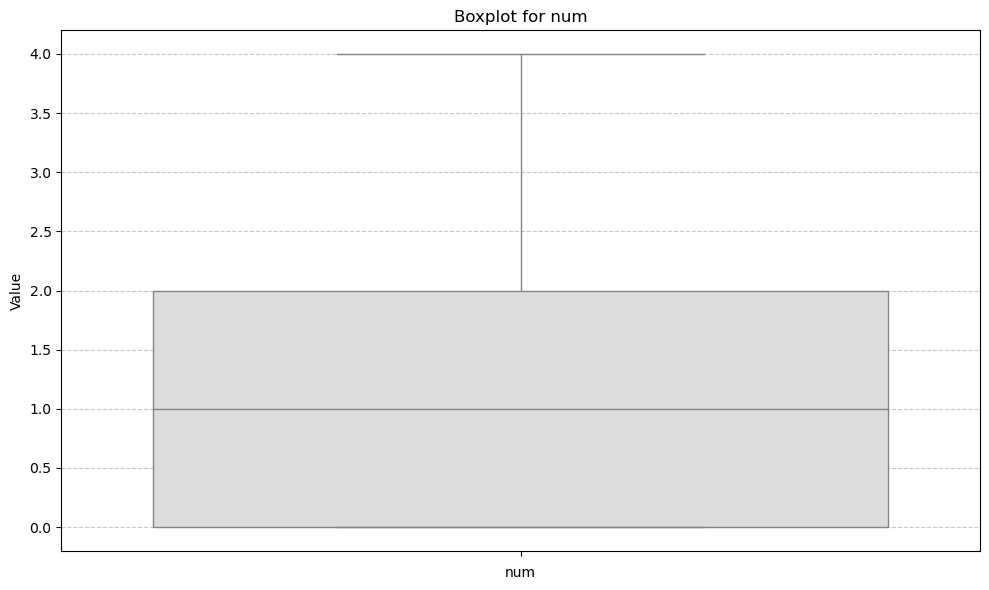

In [23]:
# Iterate through each column in the descriptive statistics and plot boxplot
for column in heart.describe().columns:
    plt.figure(figsize=(10, 6))  # Adjust figure size for better visualization
    
    # Print the column name for context in the console
    print(f"Creating boxplot for column: {column}")
    
    # Generate the boxplot
    sns.boxplot(data=heart[column], palette='coolwarm')
    plt.title(f"Boxplot for {column}")  # Add title with column name
    plt.xlabel(column)  # Set x-axis label as column name
    plt.ylabel("Value")  # Label the y-axis
    
    # Add grid for better visualization
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    
    # Show the plot
    plt.tight_layout()  # Optimize layout
    plt.show()


In [25]:
outlier_columns = ['trestbps', 'chol', 'thalch', 'oldpeak']

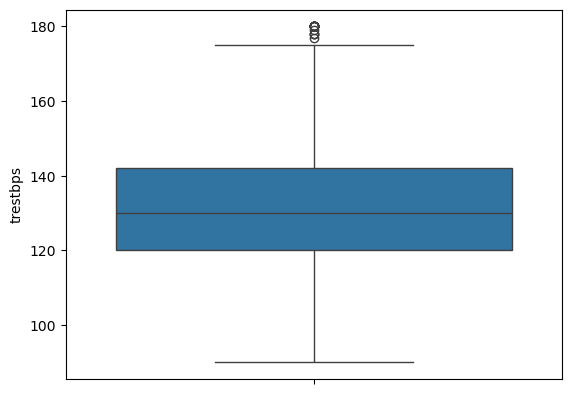

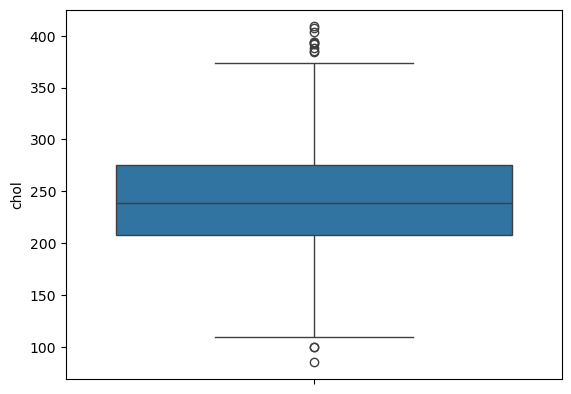

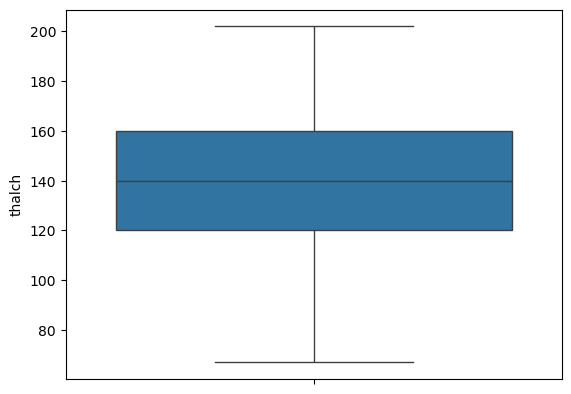

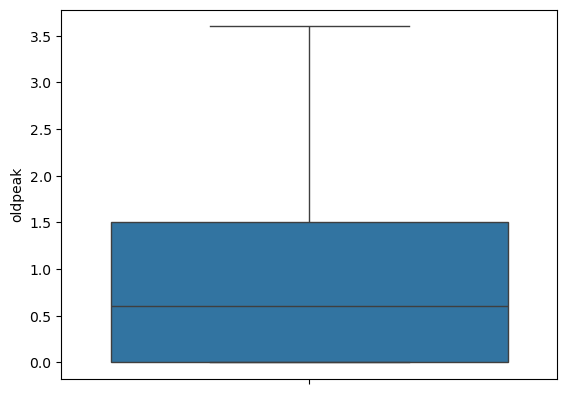

In [27]:
#Removing outliers from outlier_columns
for i in outlier_columns:
    Q1 = heart[i].quantile(0.25)
    Q3 = heart[i].quantile(0.75)
    IQR = Q3 - Q1
    upper_limit = Q3 + 1.5 * IQR
    lower_limit = Q1 - 1.5 * IQR
    heart = heart[~((heart[i] < lower_limit) | (heart[i] > upper_limit))]
    sns.boxplot(data=heart[i])
    plt.show()

Creating distplot for column: age


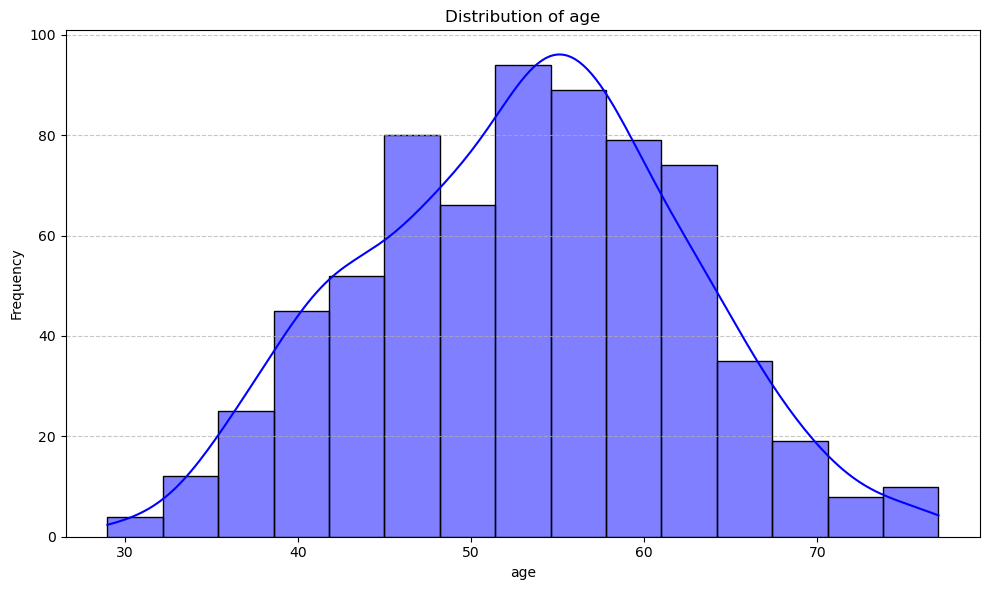

Creating distplot for column: trestbps


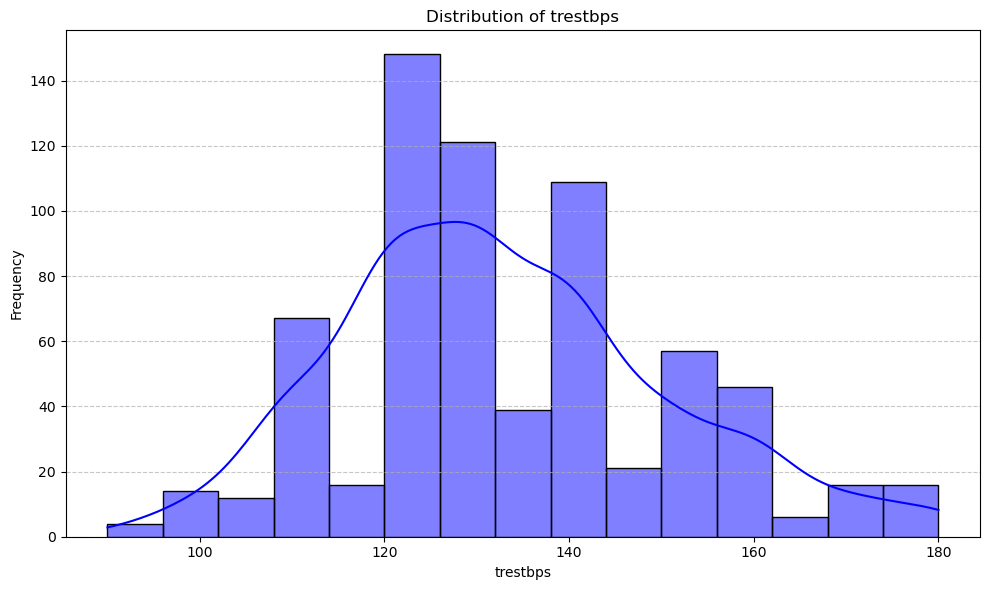

Creating distplot for column: chol


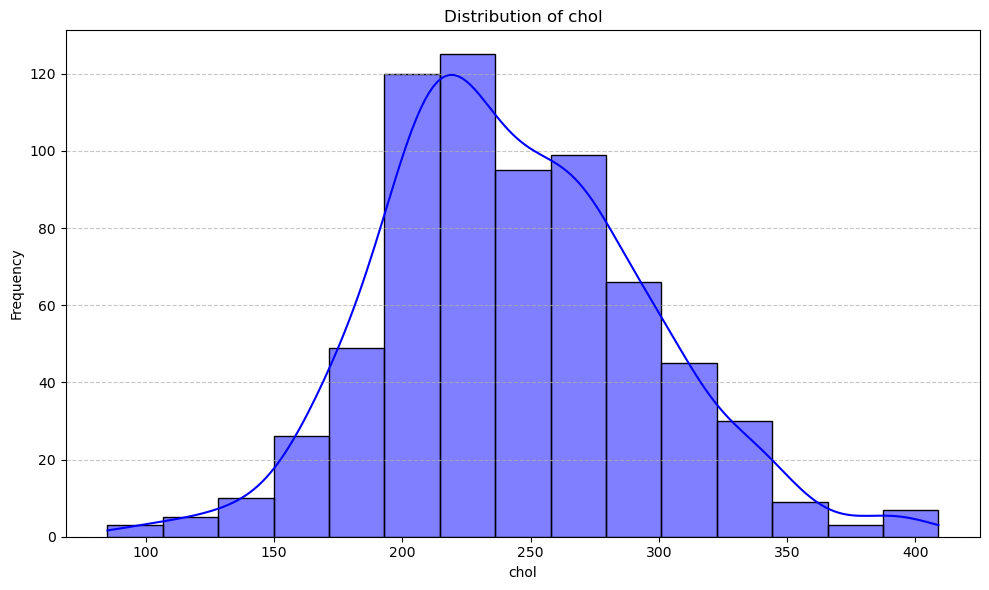

Creating distplot for column: thalch


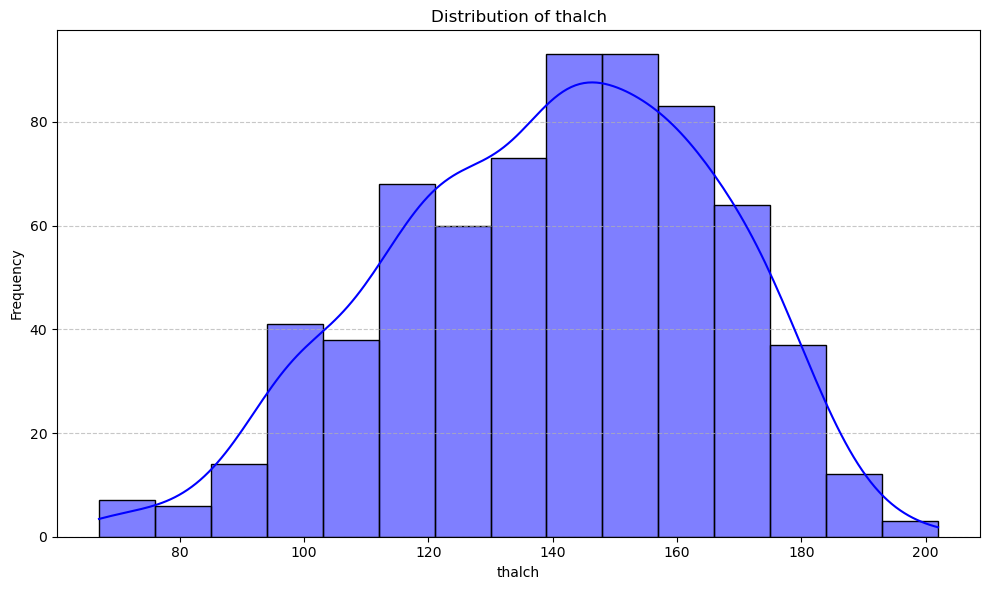

Creating distplot for column: oldpeak


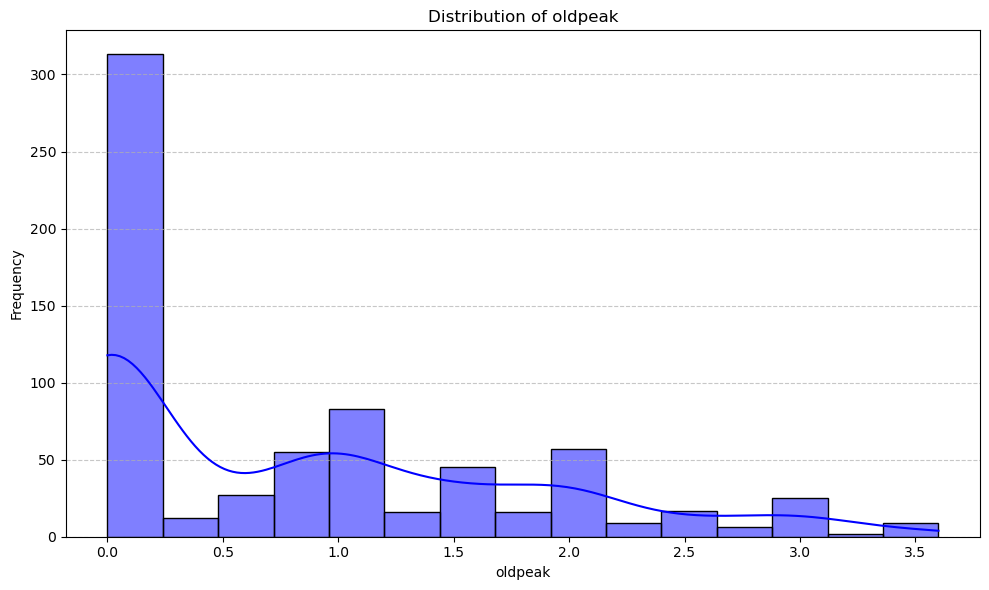

Creating distplot for column: num


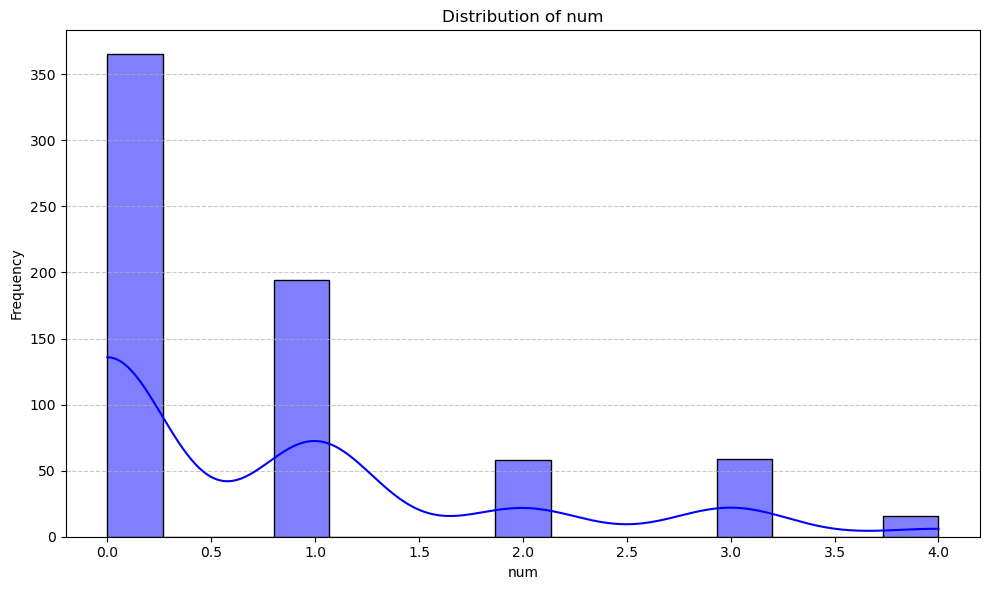

In [35]:
# Iterate through each numerical column in the dataset to plot distplot
for column in heart.columns:
    # Check if the column is numerical
    if heart[column].dtype in ['int64', 'float64']:
        plt.figure(figsize=(10, 6))  # Adjust figure size for better visualization

        # Print the column name for reference
        print(f"Creating distplot for column: {column}")
        
        # Generate the distribution plot
        sns.histplot(heart[column], kde=True, color='blue', bins=15, edgecolor='black')
        
        # Customize the plot
        plt.title(f"Distribution of {column}")
        plt.xlabel(column)
        plt.ylabel("Frequency")
        plt.grid(axis='y', linestyle='--', alpha=0.7)  # Add grid for better readability

        # Display the plot
        plt.tight_layout()
        plt.show()

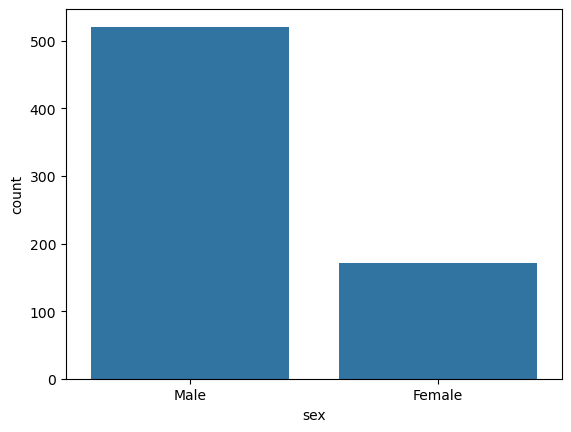

In [37]:
#Count of number of males and females in heart dataset
sns.countplot(data=heart,x='sex')
plt.show()

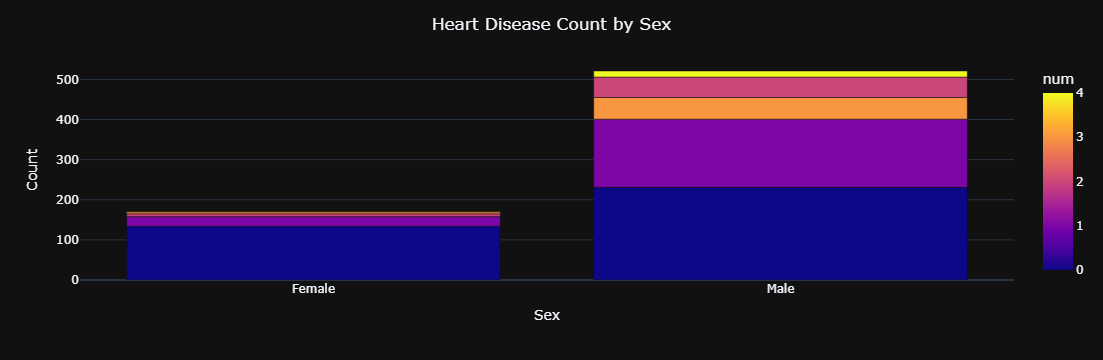

In [40]:
#grouped bar chart visualizing heart disease counts by sex using plotly.express
import plotly.express as px
data = heart.groupby('sex')['num'].value_counts().reset_index(name='count')
fig = px.bar(data, x='sex', y='count', color='num', barmode='group',template='plotly_dark')
fig.update_layout(title='Heart Disease Count by Sex',
                  title_x=0.5,
                  xaxis_title='Sex',
                  yaxis_title='Count',
                  legend_title='Heart Disease')
fig.show()

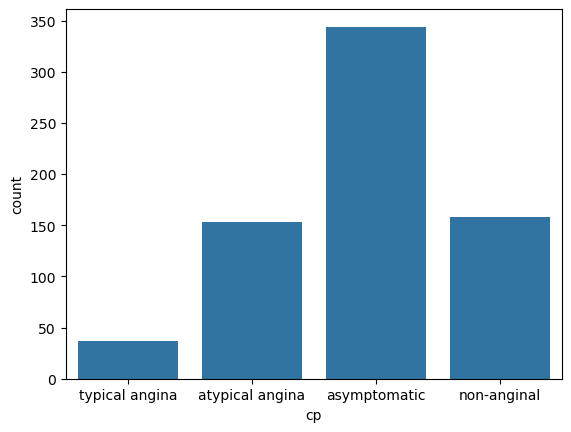

In [42]:
#heart diseasecount based on type chest pains
sns.countplot(data=heart,x='cp')
plt.show()

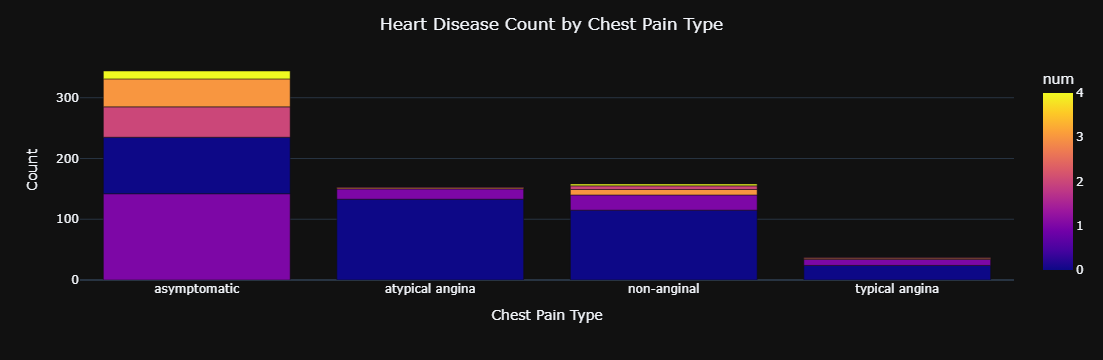

In [44]:
#grouped bar chart to visualize the count of heart disease cases (num) for each type of chest pain (cp)
data = heart.groupby('cp')['num'].value_counts().reset_index(name='count')
fig = px.bar(data, x='cp', y='count', color='num', barmode='group',template='plotly_dark')
fig.update_layout(title='Heart Disease Count by Chest Pain Type',
                  title_x=0.5,
                  xaxis_title='Chest Pain Type',
                  yaxis_title='Count',
                  legend_title='Heart Disease')
fig.show()
#You can identify trends, such as whether a specific chest pain type has more cases of diagnosed heart disease.

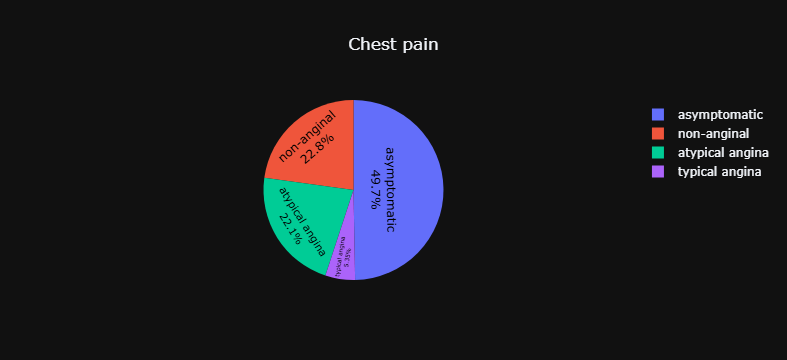

In [48]:
#pie chart that highlights the distribution of chest pain types (cp) in your dataset
fig = px.pie(heart,names='cp',title='Chest pain',template='plotly_dark')
fig.update_traces(textposition='inside', textinfo='percent+label',textfont_color='black')
fig.update_layout(title_x=0.5)
fig.show()
#From the pie chart, you can observe which chest pain type (e.g., typical angina, atypical angina, etc.) is the most or least prevalent.

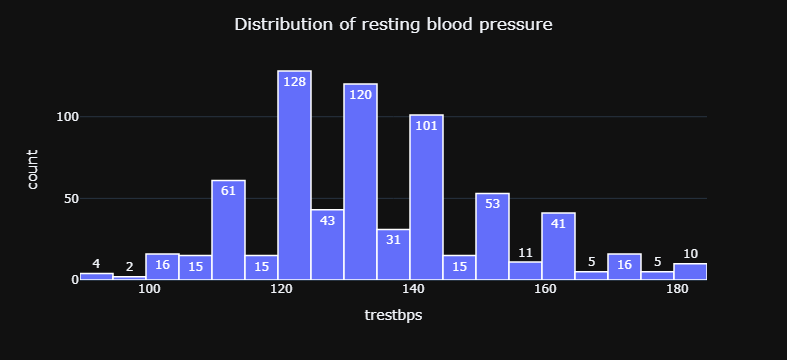

In [50]:
fig = px.histogram(heart,x='trestbps',template='plotly_dark',text_auto=True)
fig.update_traces(marker_line_width=1.5, marker_line_color='white')
fig.update_layout(title='Distribution of resting blood pressure',
                  title_x=0.5)
fig.show()
#most frequent resting blood pressure range is 130-140 mmHg but in plot highest occurence is 128mmHg which indicates there are no outliers or patients with severe hypertension

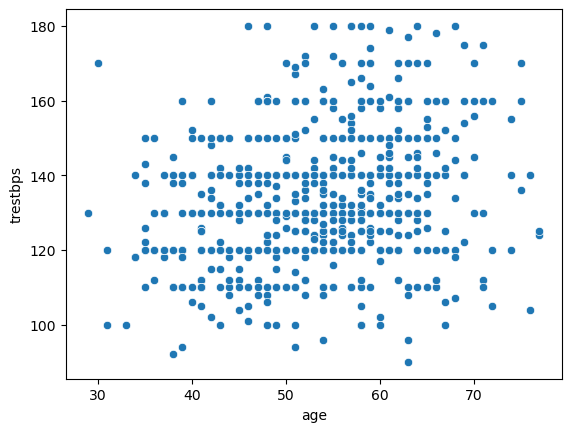

In [52]:
sns.scatterplot(data=heart,x='age',y='trestbps')
plt.show()

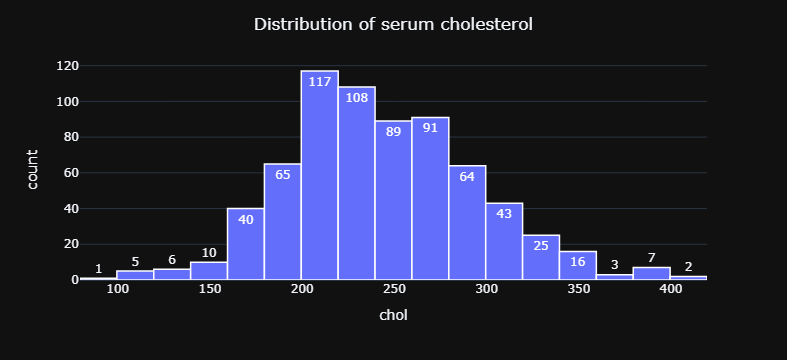

In [54]:
fig = px.histogram(heart,x='chol',template='plotly_dark',text_auto=True,nbins=25)
fig.update_traces(marker_line_width=1.5, marker_line_color='white')
fig.update_layout(title='Distribution of serum cholesterol',
                  title_x=0.5)
fig.show()
#The data shows that cholesterol levels between 275 and 300 have the most occurrences, with counts of 117 and 108 respectively.
#On the extremes (100 and above 475), the counts drop significantly, showing that extreme cholesterol levels are less common.

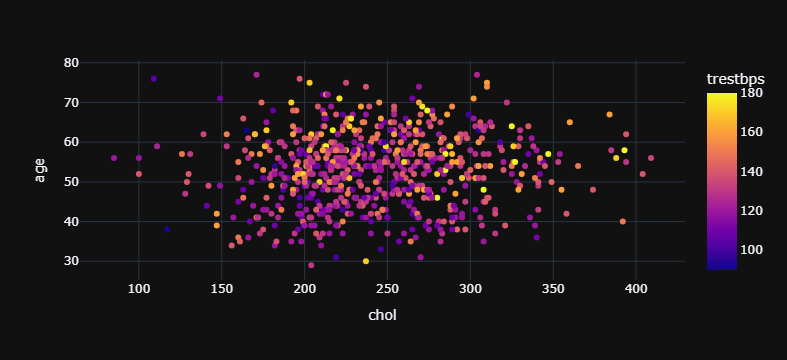

In [56]:
px.scatter(heart,x='chol',y='age',color='trestbps',template='plotly_dark')
#This plot is highly valuable for detecting patterns or correlations, such as whether high cholesterol levels are more common in certain age groups or if blood pressure changes with cholesterol levels and age.

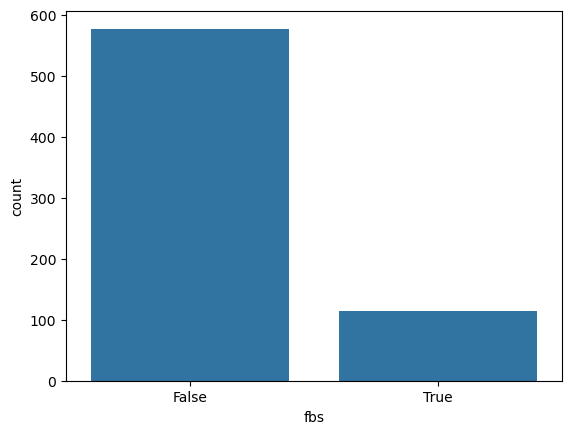

In [58]:
sns.countplot(data=heart,x='fbs')
plt.show()

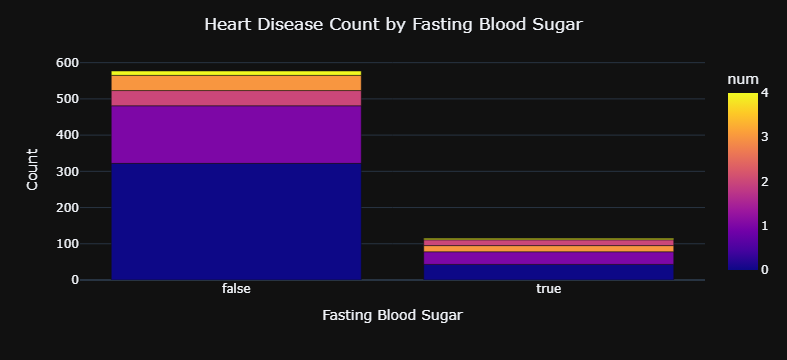

In [60]:
data = heart.groupby('fbs')['num'].value_counts().reset_index(name='count')
fig = px.bar(data, x='fbs', y='count', color='num', barmode='group',template='plotly_dark')
fig.update_layout(title='Heart Disease Count by Fasting Blood Sugar',
                  title_x=0.5,
                  xaxis_title='Fasting Blood Sugar',
                  yaxis_title='Count',
                  legend_title='Heart Disease')
fig.show()
#It highlights that the majority of heart disease occurrences are among individuals with "false" fasting blood sugar levels, while fewer cases are seen in those with "true" fasting blood sugar. The color-coded bars also provide insights into the severity of heart disease within these groups

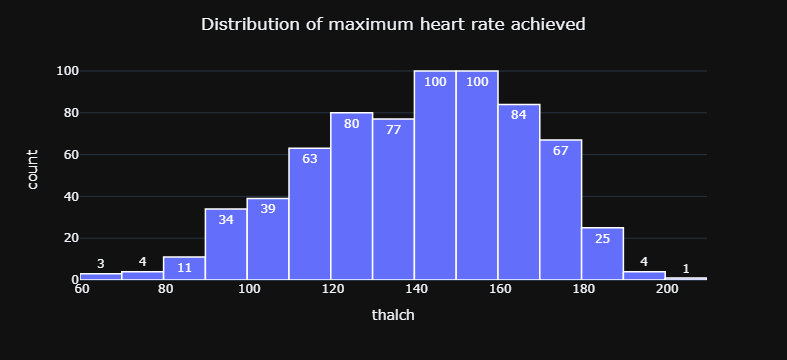

In [62]:
fig = px.histogram(heart,x='thalch',nbins=15,template='plotly_dark',text_auto=True)
fig.update_traces(marker_line_width=1.5, marker_line_color='white')
fig.update_layout(title='Distribution of maximum heart rate achieved',
                  title_x=0.5)
fig.show()

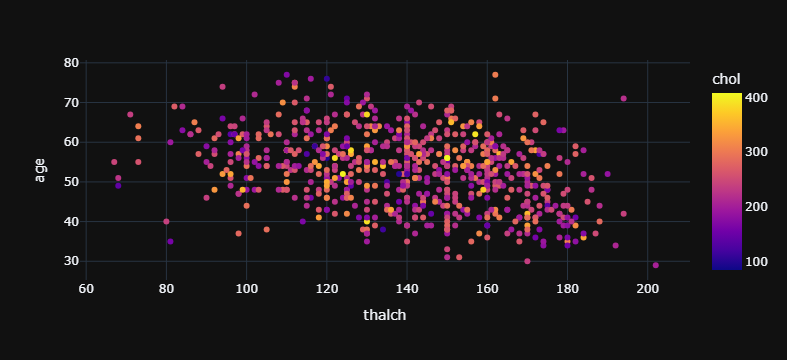

In [64]:
px.scatter(heart,x='thalch',y='age',color='chol',template='plotly_dark')

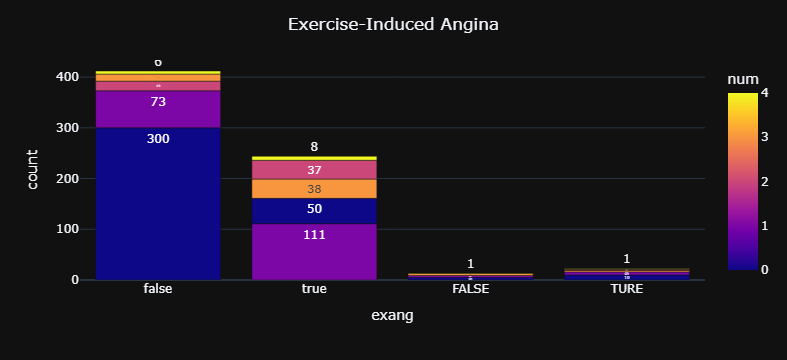

In [68]:
data = heart.groupby('exang')['num'].value_counts().reset_index(name='count')
fig = px.bar(data, x='exang', y='count', color='num',template='plotly_dark',text_auto=True)
fig.update_layout(title='Exercise-Induced Angina',
                  title_x=0.5)
fig.show()

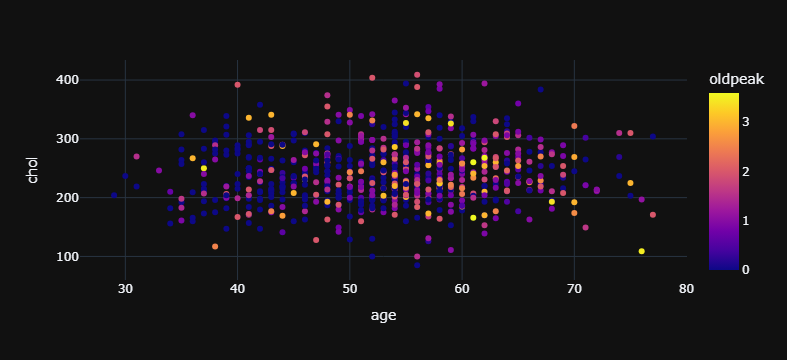

In [70]:
px.scatter(heart,x='age',y='chol',color='oldpeak',template='plotly_dark')

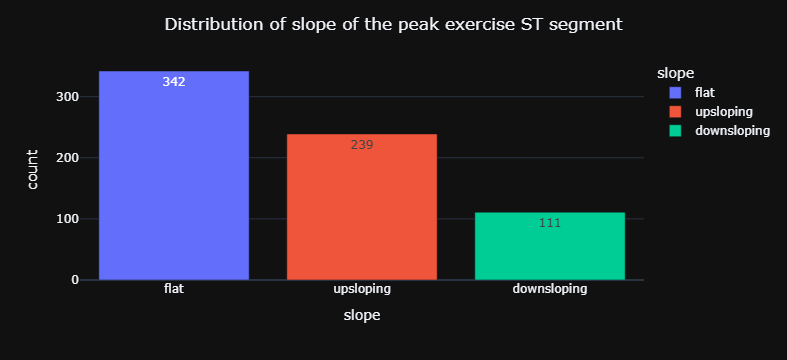

In [72]:
data = heart['slope'].value_counts().reset_index()
fig = px.bar(data, x='slope', y='count',color='slope',template='plotly_dark',text_auto=True)
fig.update_layout(title='Distribution of slope of the peak exercise ST segment',
                  title_x=0.5)
fig.show()

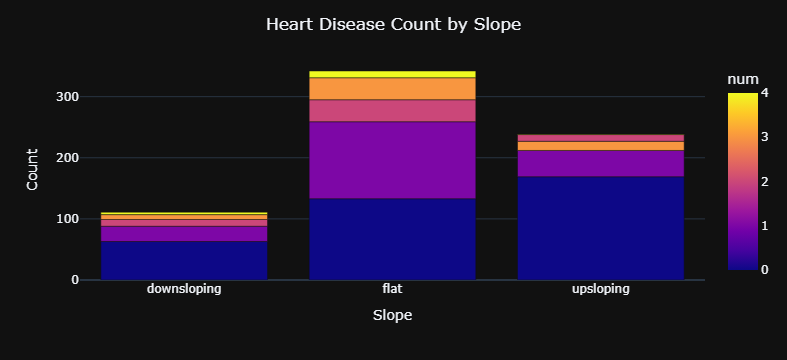

In [74]:
data = heart.groupby('slope')['num'].value_counts().reset_index(name='count')
fig = px.bar(data, x='slope', y='count', color='num',barmode='group',template='plotly_dark')
fig.update_layout(title='Heart Disease Count by Slope',
                  title_x=0.5,
                  xaxis_title='Slope',
                  yaxis_title='Count',
                  legend_title='Heart Disease')
fig.show()

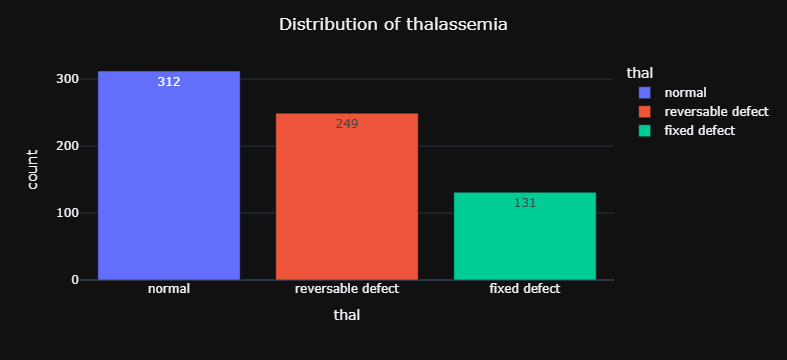

In [76]:
data = heart['thal'].value_counts().reset_index()
fig = px.bar(data, x='thal', y='count',color='thal',template='plotly_dark',text_auto=True)
fig.update_layout(title='Distribution of thalassemia',
                  title_x=0.5)
fig.show()

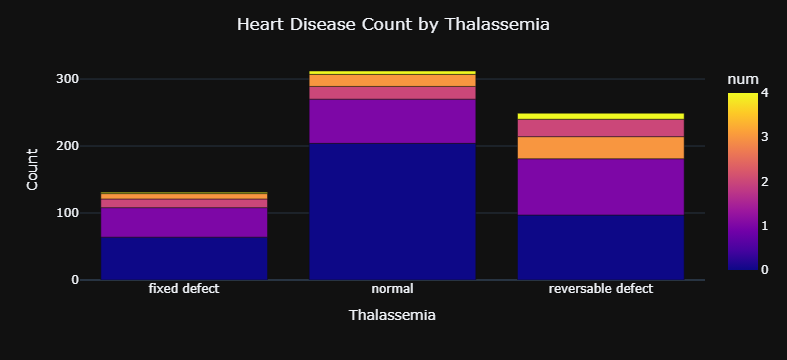

In [78]:
data = heart.groupby('thal')['num'].value_counts().reset_index(name='count')
fig = px.bar(data, x='thal', y='count', color='num',barmode='group',template='plotly_dark')
fig.update_layout(title='Heart Disease Count by Thalassemia',
                  title_x=0.5,
                  xaxis_title='Thalassemia',
                  yaxis_title='Count',
                  legend_title='Heart Disease')
fig.show()

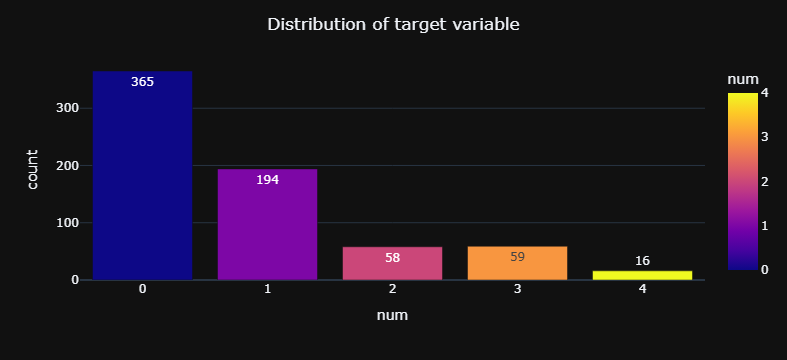

In [80]:
data = heart['num'].value_counts().reset_index()
fig = px.bar(data, x='num', y='count',color='num',template='plotly_dark',text_auto=True)
fig.update_layout(title='Distribution of target variable',
                  title_x=0.5)
fig.show()

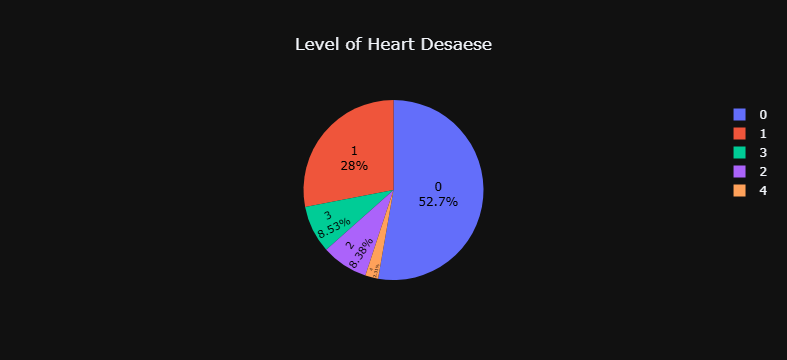

In [82]:
fig = px.pie(heart,names='num',title='Level of Heart Desaese',template='plotly_dark')
fig.update_traces(textposition='inside', textinfo='percent+label',textfont_color='black')
fig.update_layout(title_x=0.5)
fig.show()

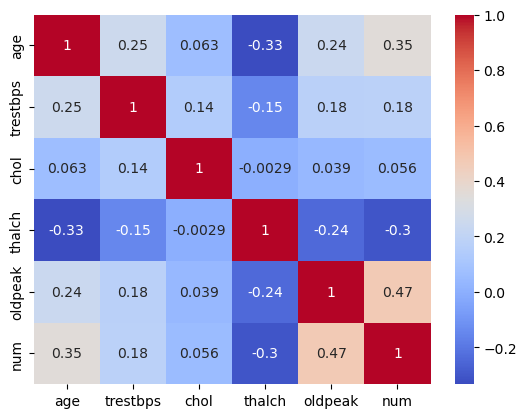

In [84]:
corr = heart[heart.describe().columns].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

In [ ]:
# Oldpeak and Heart Disease (Num): The strongest correlation is between oldpeak (ST depression from exercise) and num (indicating heart disease presence), with a value of 0.47. This suggests that higher oldpeak values might be linked to greater chances of heart disease.

# Age and Heart Disease: Age also shows a moderate positive correlation with num (0.35), meaning older individuals might have a higher association with heart disease.

# Thalach (Max Heart Rate): Thalach has a negative correlation with num (-0.3), indicating that a higher maximum heart rate achieved during exercise may be linked to a lower likelihood of heart disease.

# Other Observations:

# Age and Oldpeak have a positive correlation (0.24), potentially suggesting that older individuals may experience more exercise-induced ST depression.

# Cholesterol (Chol) shows weak correlations with other features, making it less impactful in this specific dataset.

In [86]:
#Feature engineering
from sklearn.preprocessing import LabelEncoder, StandardScaler

In [88]:
label_encoder = LabelEncoder()
label_encoder

LabelEncoder()

In [90]:
heart['sex'] = label_encoder.fit_transform(heart['sex'])
heart['cp'] = label_encoder.fit_transform(heart['cp'])
heart['fbs'] = label_encoder.fit_transform(heart['fbs'])
heart['restecg'] = label_encoder.fit_transform(heart['restecg'])
heart['slope'] = label_encoder.fit_transform(heart['slope'])
heart['thal'] = label_encoder.fit_transform(heart['thal'])
heart.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal,num
0,63,1,3,145,233,1,0,150,False,2.3,0,0,0
1,41,1,1,135,203,0,1,132,False,0.0,1,0,0
2,57,1,0,140,192,0,1,148,False,0.4,1,0,0
3,52,1,3,118,186,0,0,190,False,0.0,1,0,0
4,57,1,0,110,201,0,1,126,True,1.5,1,0,0


In [92]:
heart['exang'] = heart['exang'].astype(bool)
heart['exang'] = heart['exang'].astype(int)
heart.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal,num
0,63,1,3,145,233,1,0,150,0,2.3,0,0,0
1,41,1,1,135,203,0,1,132,0,0.0,1,0,0
2,57,1,0,140,192,0,1,148,0,0.4,1,0,0
3,52,1,3,118,186,0,0,190,0,0.0,1,0,0
4,57,1,0,110,201,0,1,126,1,1.5,1,0,0


In [98]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# Select only numerical columns
numerical_columns = heart.select_dtypes(include=['int64', 'float64']).columns

# Initialize scalers
standard_scaler = StandardScaler()
minmax_scaler = MinMaxScaler()

# Apply Standard Scaling
heart_disease_standard_scaled = heart.copy()
heart_disease_standard_scaled[numerical_columns] = standard_scaler.fit_transform(heart[numerical_columns])

# Apply Min-Max Scaling
heart_disease_minmax_scaled = heart.copy()
heart_disease_minmax_scaled[numerical_columns] = minmax_scaler.fit_transform(heart[numerical_columns])

# Display scaled datasets
print("Standard Scaled Dataset (first 5 rows):")
print(heart_disease_standard_scaled.head())

print("\nMin-Max Scaled Dataset (first 5 rows):")
print(heart_disease_minmax_scaled.head())


Standard Scaled Dataset (first 5 rows):
        age  sex  cp  trestbps      chol       fbs  restecg    thalch  exang  \
0  1.085850    1   3  0.689832 -0.194128  2.239953        0  0.407050      0   
1 -1.325672    1   1  0.122690 -0.777357 -0.446438        1 -0.291712      0   
2  0.428162    1   0  0.406261 -0.991207 -0.446438        1  0.329410      0   
3 -0.119911    1   3 -0.841452 -1.107852 -0.446438        0  1.959853      0   
4  0.428162    1   0 -1.295166 -0.816238 -0.446438        1 -0.524632      1   

    oldpeak  slope  thal       num  
0  1.529430      0     0 -0.752753  
1 -0.887812      1     0 -0.752753  
2 -0.467422      1     0 -0.752753  
3 -0.887812      1     0 -0.752753  
4  0.688650      1     0 -0.752753  

Min-Max Scaled Dataset (first 5 rows):
        age  sex  cp  trestbps      chol  fbs  restecg    thalch  exang  \
0  0.708333    1   3  0.611111  0.456790  1.0        0  0.614815      0   
1  0.250000    1   1  0.500000  0.364198  0.0        1  0.481481   

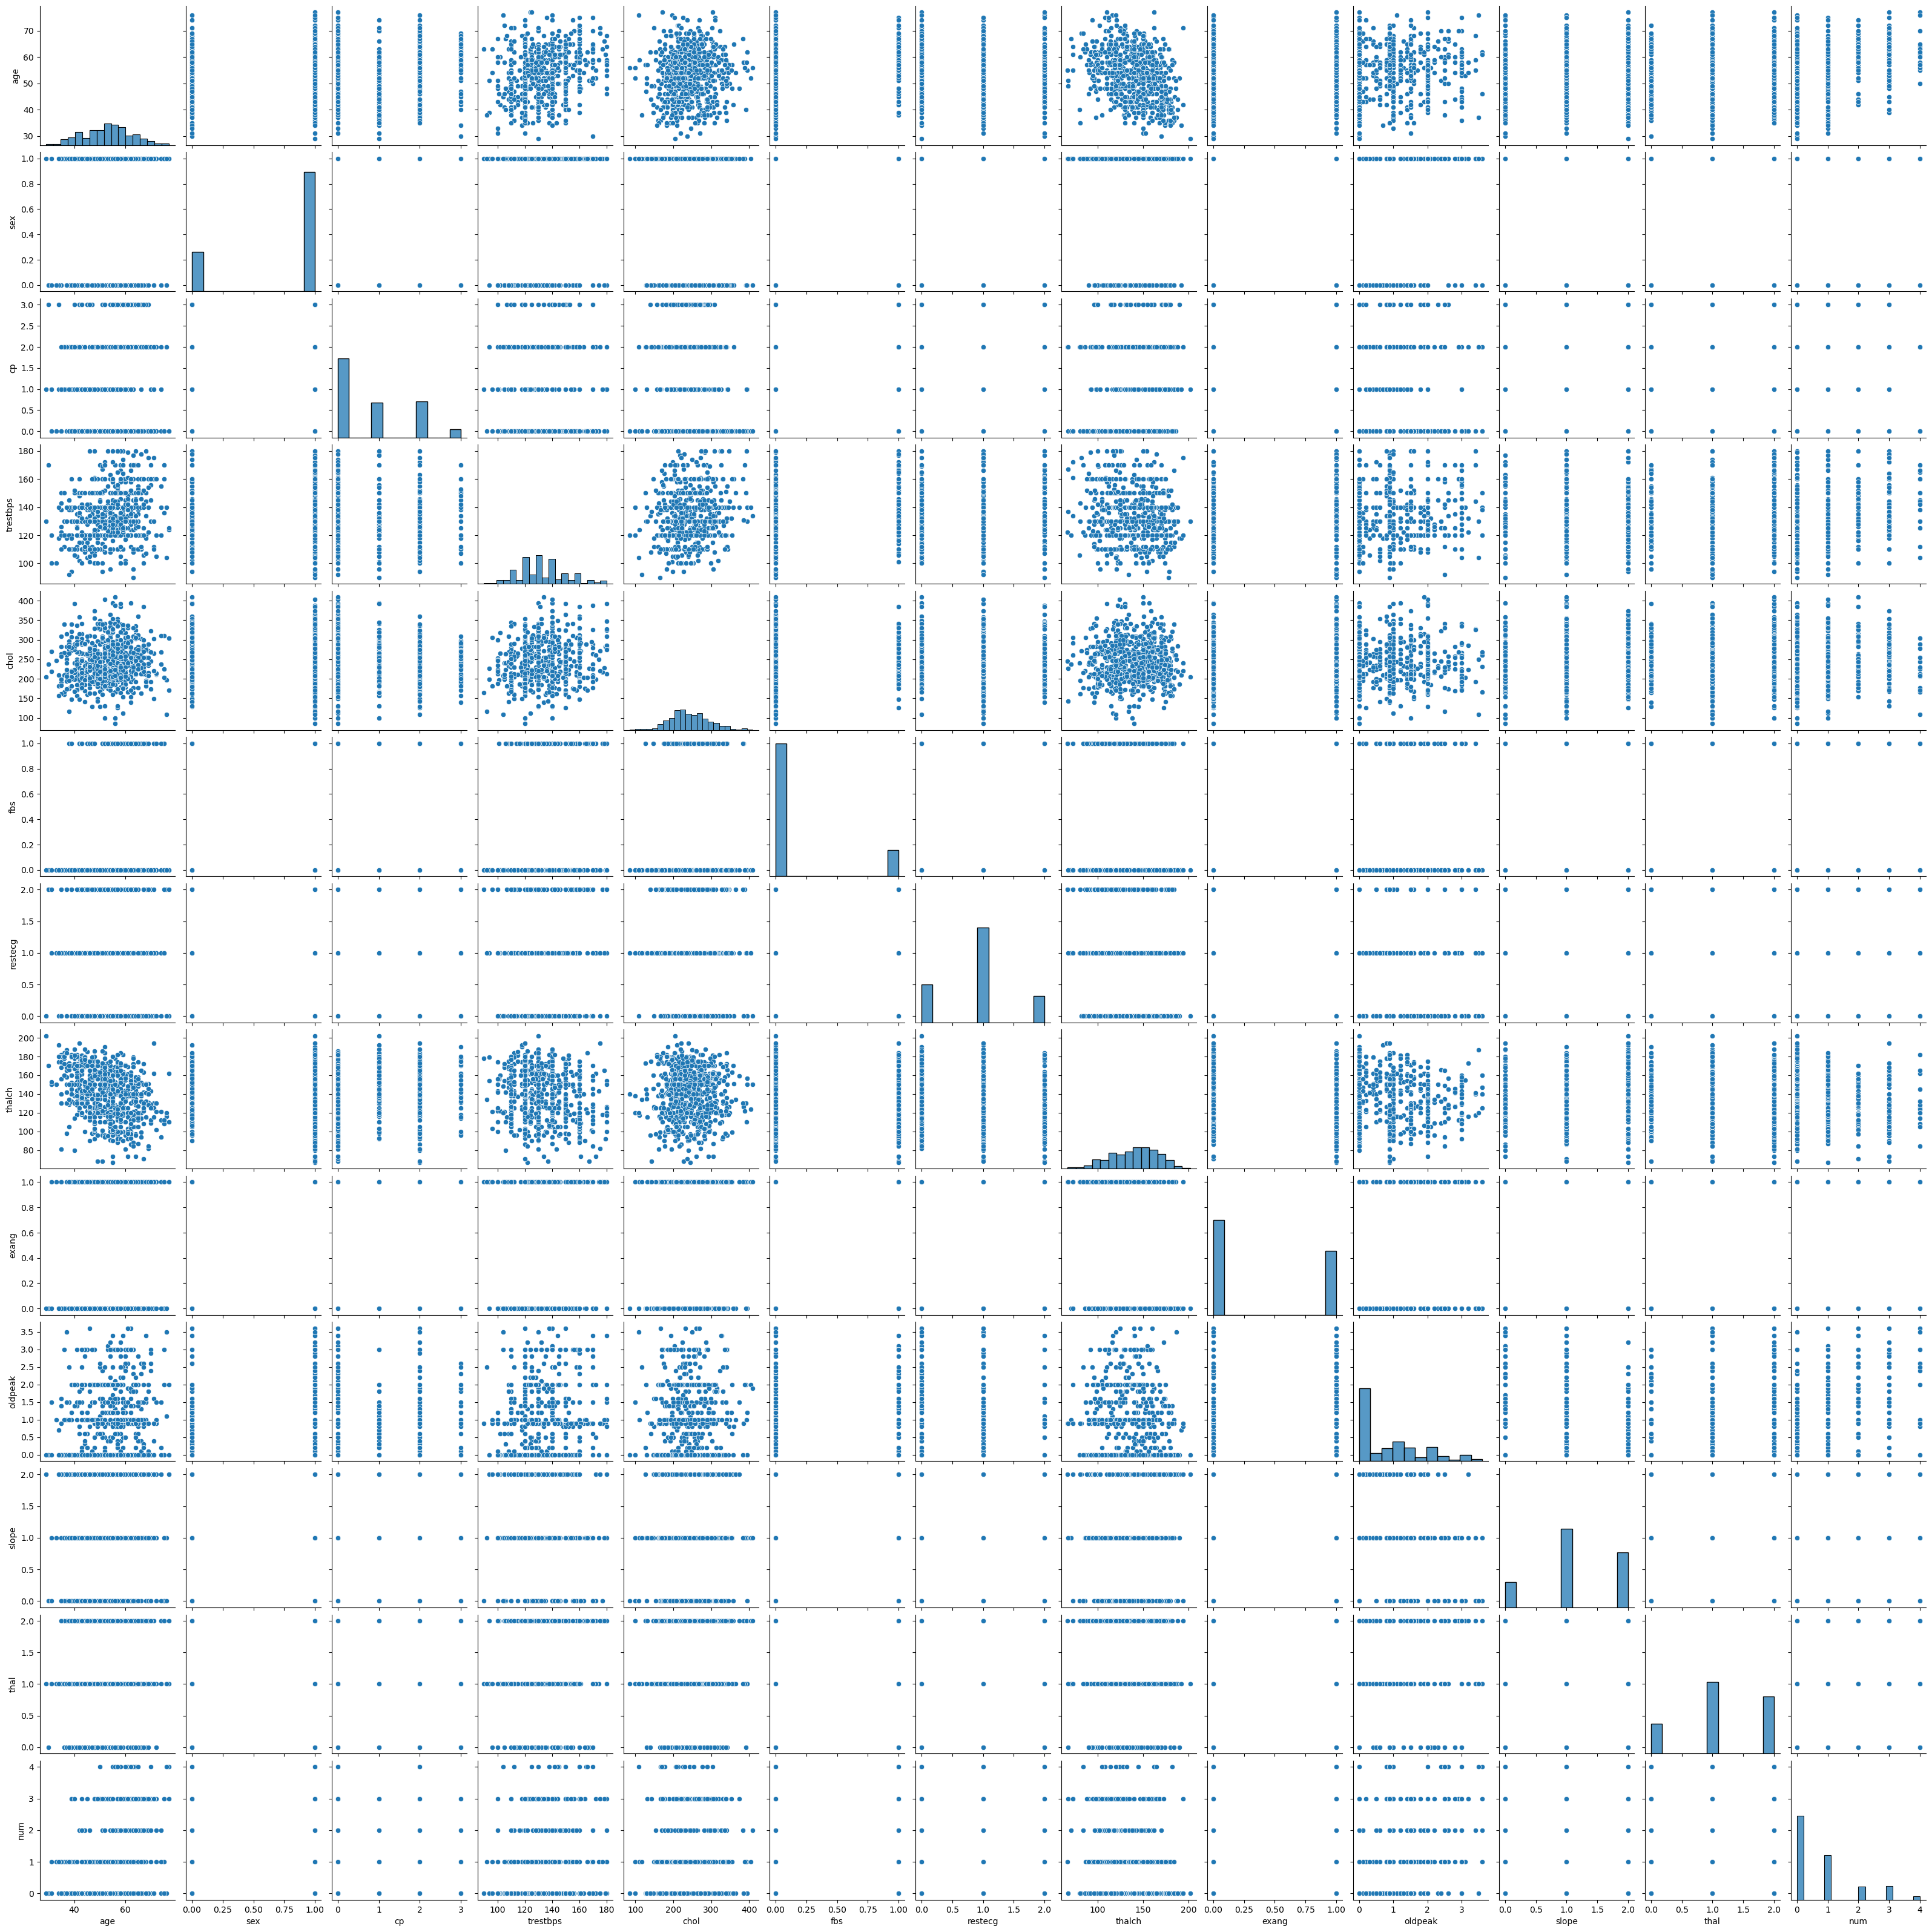

In [100]:
sns.pairplot(heart)
plt.show()

In [101]:
#Decision tree classifier
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn import tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc, roc_auc_score

In [104]:
X = heart.drop('num', axis=1)
y = heart['num']

In [106]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [108]:
Decision_tree = DecisionTreeClassifier(criterion='entropy',max_depth=5)
Decision_tree.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=5)

In [110]:
print('Train Accuracy:', Decision_tree.score(X_train, y_train))
print('Test Accuracy:', Decision_tree.score(X_test, y_test))

Train Accuracy: 0.6943942133815552
Test Accuracy: 0.5755395683453237


In [112]:
y_pred = Decision_tree.predict(X_test)
y_pred

array([1, 1, 0, 0, 0, 0, 3, 0, 0, 0, 0, 0, 3, 0, 0, 3, 1, 0, 1, 0, 1, 0,
       0, 1, 2, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 0, 2, 0, 0, 0, 0, 0, 1, 0,
       0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 3, 0, 1, 1, 0, 0, 1,
       0, 1, 0, 0, 0, 0, 0, 0, 0, 3, 1, 1, 0, 0, 0, 1, 3, 0, 0, 0, 0, 1,
       0, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       1, 1, 0, 0, 1, 3, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1,
       1, 0, 1, 0, 0, 1, 0], dtype=int64)

In [118]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.77      0.82      0.79        82
           1       0.31      0.43      0.36        30
           2       0.00      0.00      0.00        10
           3       0.00      0.00      0.00        14
           4       0.00      0.00      0.00         3

    accuracy                           0.58       139
   macro avg       0.22      0.25      0.23       139
weighted avg       0.52      0.58      0.55       139



In [ ]:
#Class '0' Performs Best:Precision: 77%,Recall: 82%,F1-Score: 79%
#It's the most accurately predicted class, with 67 correct out of 82 cases.

#Challenges with Classes '2', '3', and '4':These classes show 0% precision, recall, and F1-scores, indicating the model struggles to identify or classify these categories accurately.

#Overall Accuracy:The model achieves 58% accuracy, meaning it correctly predicts slightly more than half of the cases in the test dataset.

In [120]:
conf_matrix = confusion_matrix(y_test, y_pred)
conf_matrix

array([[67, 14,  1,  0,  0],
       [11, 13,  1,  5,  0],
       [ 4,  6,  0,  0,  0],
       [ 5,  8,  1,  0,  0],
       [ 0,  1,  0,  2,  0]], dtype=int64)

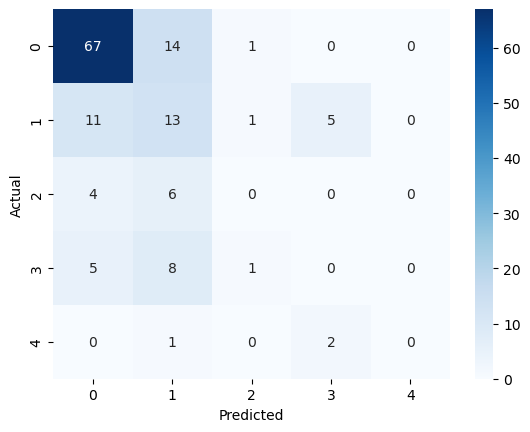

In [122]:
sns.heatmap(conf_matrix, annot=True, cmap='Blues', fmt='g')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [ ]:
#Class '0': Most predictions are accurate (67), but 14 cases are misclassified.

#Class '1': Moderate performance with 13 correct predictions, but 18 are misclassified (11 as '0', 5 as '2', 1 as '3').

In [124]:
y_pred_proba = Decision_tree.predict_proba(X_test) # Get predicted probabilities
print('ROC Score is:', roc_auc_score(y_test, y_pred_proba, multi_class='ovr'))

ROC Score is: 0.7119460577175276


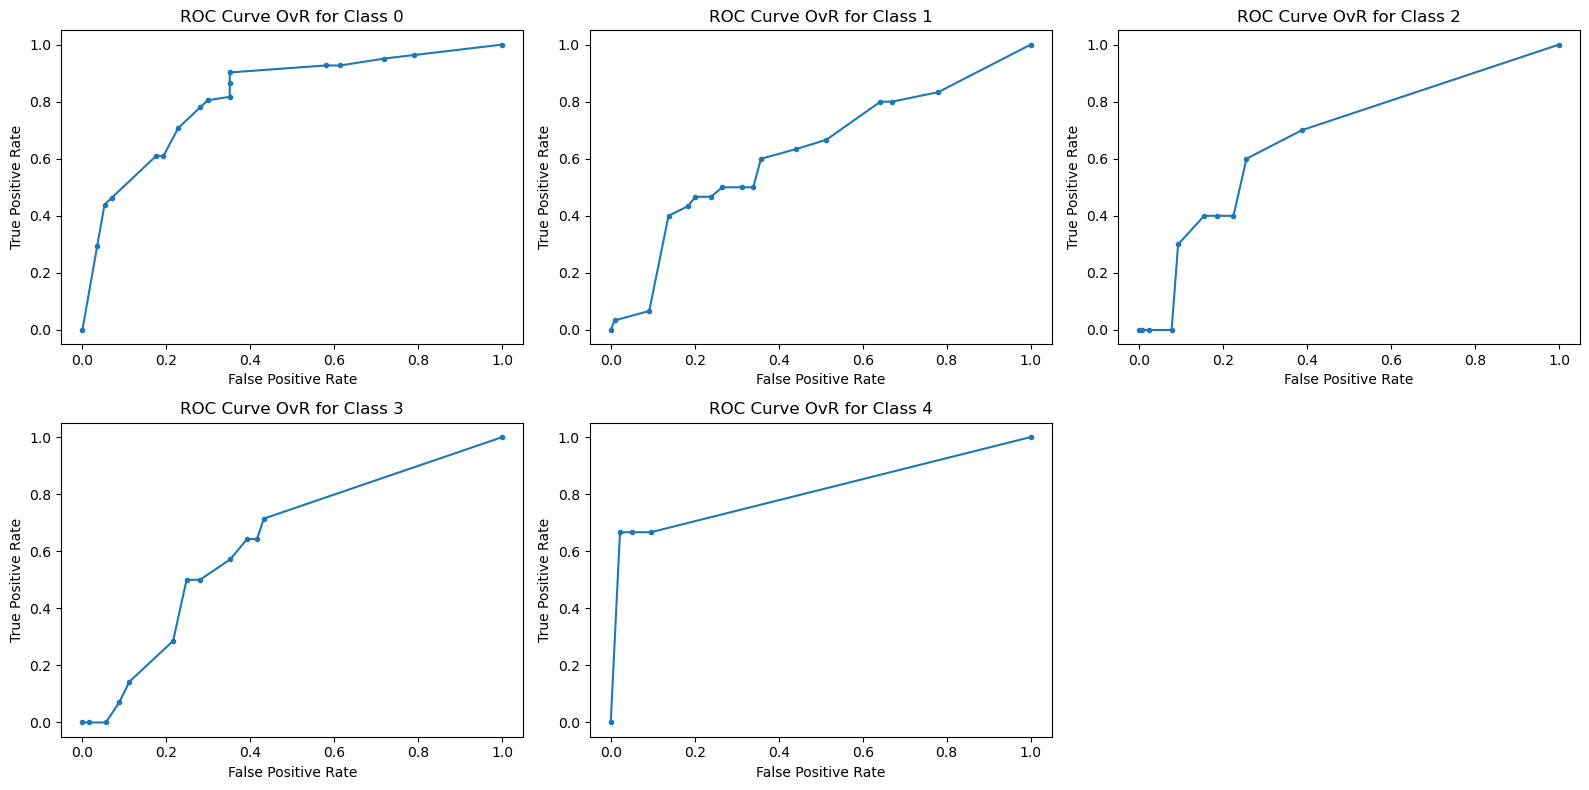

ROC AUC OvR for class 0: 0.82
ROC AUC OvR for class 1: 0.63
ROC AUC OvR for class 2: 0.67
ROC AUC OvR for class 3: 0.63
ROC AUC OvR for class 4: 0.81


In [126]:
plt.figure(figsize=(16, 8))
classes = Decision_tree.classes_  # Assuming this gives the list of class labels
roc_auc_ovr = {}

for i in range(len(classes)):
    # Gets the class
    c = classes[i]

    # Prepares an auxiliary dataframe to help with the ROC curve
    df_aux = X_test.copy()  # X_test is your test data (features)
    df_aux['class'] = [1 if y == c else 0 for y in y_test]  # y_test is your test data (true labels)
    df_aux['prob'] = y_pred_proba[:, i]  # y_proba is the predicted probabilities from the model

    # Calculates the ROC Coordinates and plots the ROC Curves
    fpr, tpr, _ = roc_curve(df_aux['class'], df_aux['prob'])
    ax = plt.subplot(2, 3, i+1)
    ax.plot(fpr, tpr, marker='.')
    ax.set_title(f"ROC Curve OvR for Class {c}")
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")

    # Calculates the ROC AUC OvR
    roc_auc_ovr[c] = roc_auc_score(df_aux['class'], df_aux['prob'])

plt.tight_layout()
plt.show()

# Print ROC AUC scores
for c in roc_auc_ovr:
    print(f"ROC AUC OvR for class {c}: {roc_auc_ovr[c]:.2f}")

In [ ]:
# Best Predictions: The model does a good job predicting for Class 0 and Class 4, with high accuracy.

# Decent for Class 2: The model is okay at predicting Class 2 but could do better.

# Struggles with Class 1 and Class 3: These two classes are the hardest for the model to predict.

# Improve the Model: To fix the issues, try balancing the data or tweaking the model.

In [128]:
#Hyperparameter tunning
from sklearn.model_selection import GridSearchCV

In [130]:
param_grid = {
    'criterion': ['gini', 'entropy'],  # Criterion for splitting
    'max_depth': [None, 5,10, 20, 30, 40, 50],  # Maximum depth of the tree
}

In [132]:
dt = DecisionTreeClassifier(random_state=42)

In [134]:
grid_search = GridSearchCV(estimator=dt, param_grid=param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 14 candidates, totalling 70 fits


GridSearchCV(cv=5, estimator=DecisionTreeClassifier(random_state=42), n_jobs=-1,
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [None, 5, 10, 20, 30, 40, 50]},
             scoring='accuracy', verbose=1)

In [136]:
print("Best Parameters:", grid_search.best_params_)
best_model = grid_search.best_estimator_

Best Parameters: {'criterion': 'gini', 'max_depth': 5}


In [138]:
#Model evaluation and Analysis
y_pred = best_model.predict(X_test)
print("Classification Report:\n", classification_report(y_test, y_pred))

Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.82      0.83        82
           1       0.38      0.63      0.47        30
           2       0.33      0.10      0.15        10
           3       0.17      0.07      0.10        14
           4       0.00      0.00      0.00         3

    accuracy                           0.63       139
   macro avg       0.35      0.32      0.31       139
weighted avg       0.62      0.63      0.61       139



In [ ]:
#Class 0 performs the best with high accuracy (precision 85%, recall 82%). Class 1 has moderate results, but classes 2, 3, and 4 show very low or no performance. Overall model accuracy is 63%, so improvement is needed for underperforming classes.

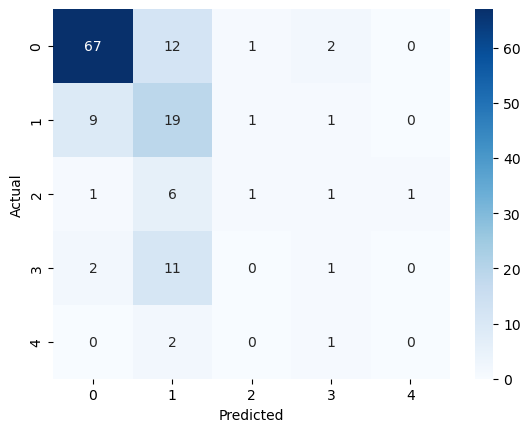

In [140]:
conf_matrix = confusion_matrix(y_test, y_pred)
sns.heatmap(conf_matrix, annot=True, cmap='Blues', fmt='g')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [142]:
y_pred_proba = best_model.predict_proba(X_test) # Get predicted probabilities
print('ROC Score is:', roc_auc_score(y_test, y_pred_proba, multi_class='ovr'))

ROC Score is: 0.7764139147416053


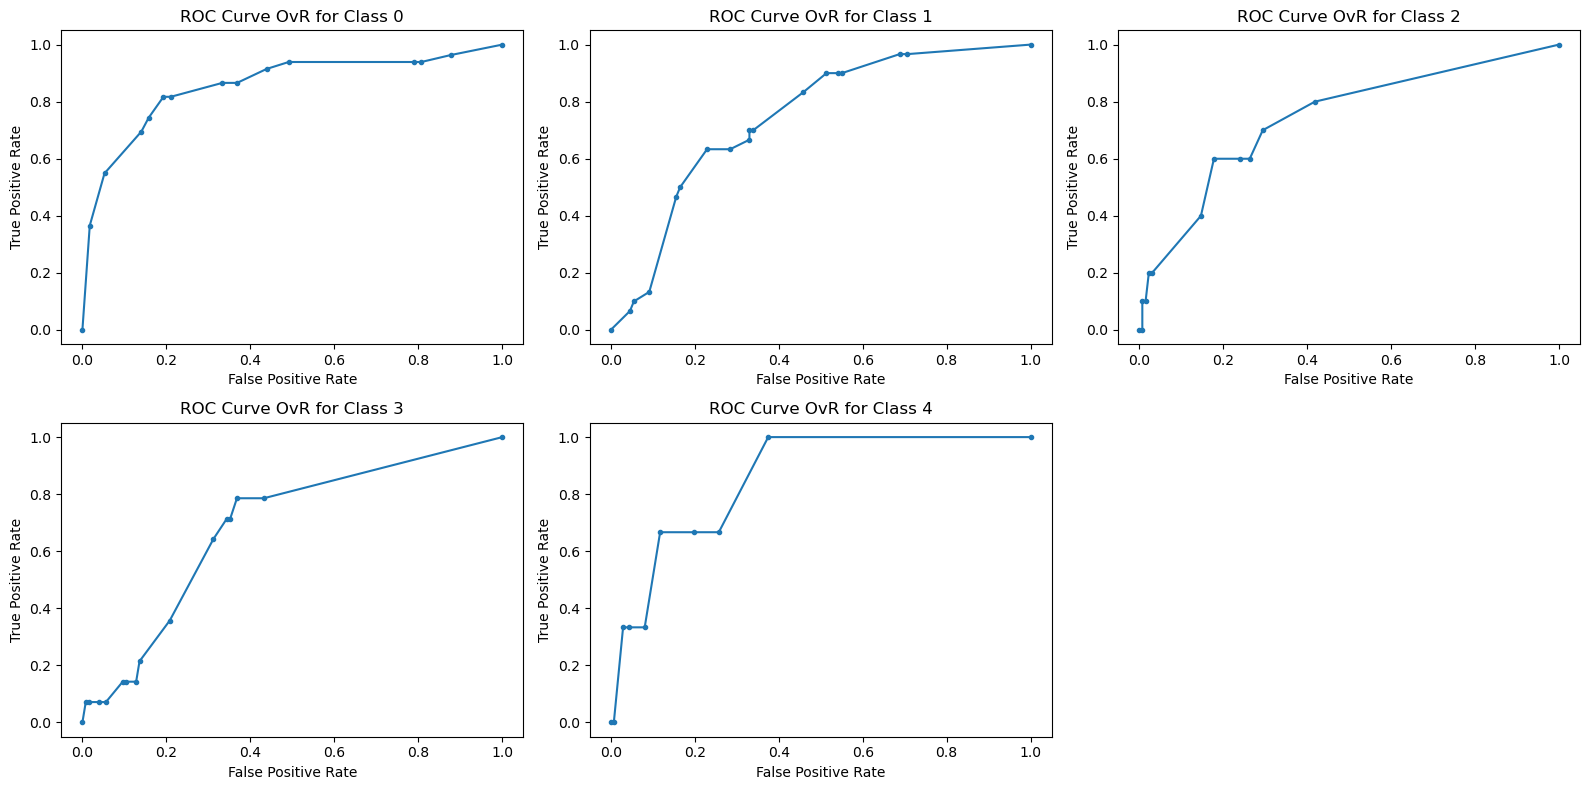

ROC AUC OvR for class 0: 0.86
ROC AUC OvR for class 1: 0.74
ROC AUC OvR for class 2: 0.74
ROC AUC OvR for class 3: 0.68
ROC AUC OvR for class 4: 0.86


In [144]:
plt.figure(figsize=(16, 8))
classes = best_model.classes_  # Assuming this gives the list of class labels
roc_auc_ovr = {}

for i in range(len(classes)):
    # Gets the class
    c = classes[i]

    # Prepares an auxiliary dataframe to help with the ROC curve
    df_aux = X_test.copy()  # X_test is your test data (features)
    df_aux['class'] = [1 if y == c else 0 for y in y_test]  # y_test is your test data (true labels)
    df_aux['prob'] = y_pred_proba[:, i]  # y_proba is the predicted probabilities from the model

    # Calculates the ROC Coordinates and plots the ROC Curves
    fpr, tpr, _ = roc_curve(df_aux['class'], df_aux['prob'])
    ax = plt.subplot(2, 3, i+1)
    ax.plot(fpr, tpr, marker='.')
    ax.set_title(f"ROC Curve OvR for Class {c}")
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")

    # Calculates the ROC AUC OvR
    roc_auc_ovr[c] = roc_auc_score(df_aux['class'], df_aux['prob'])

plt.tight_layout()
plt.show()

# Print ROC AUC scores
for c in roc_auc_ovr:
    print(f"ROC AUC OvR for class {c}: {roc_auc_ovr[c]:.2f}")

In [ ]:
# Strongest Classes:Class 0 and Class 4 both have the highest ROC AUC scores of 0.86, showing excellent predictive performance.

# Moderate Performance:Class 1 and Class 2 each have ROC AUC values of 0.74, indicating moderate performance for these classes.

# Weakest Class:Class 3 has the lowest ROC AUC score of 0.68, meaning the model struggles the most with predicting this class.

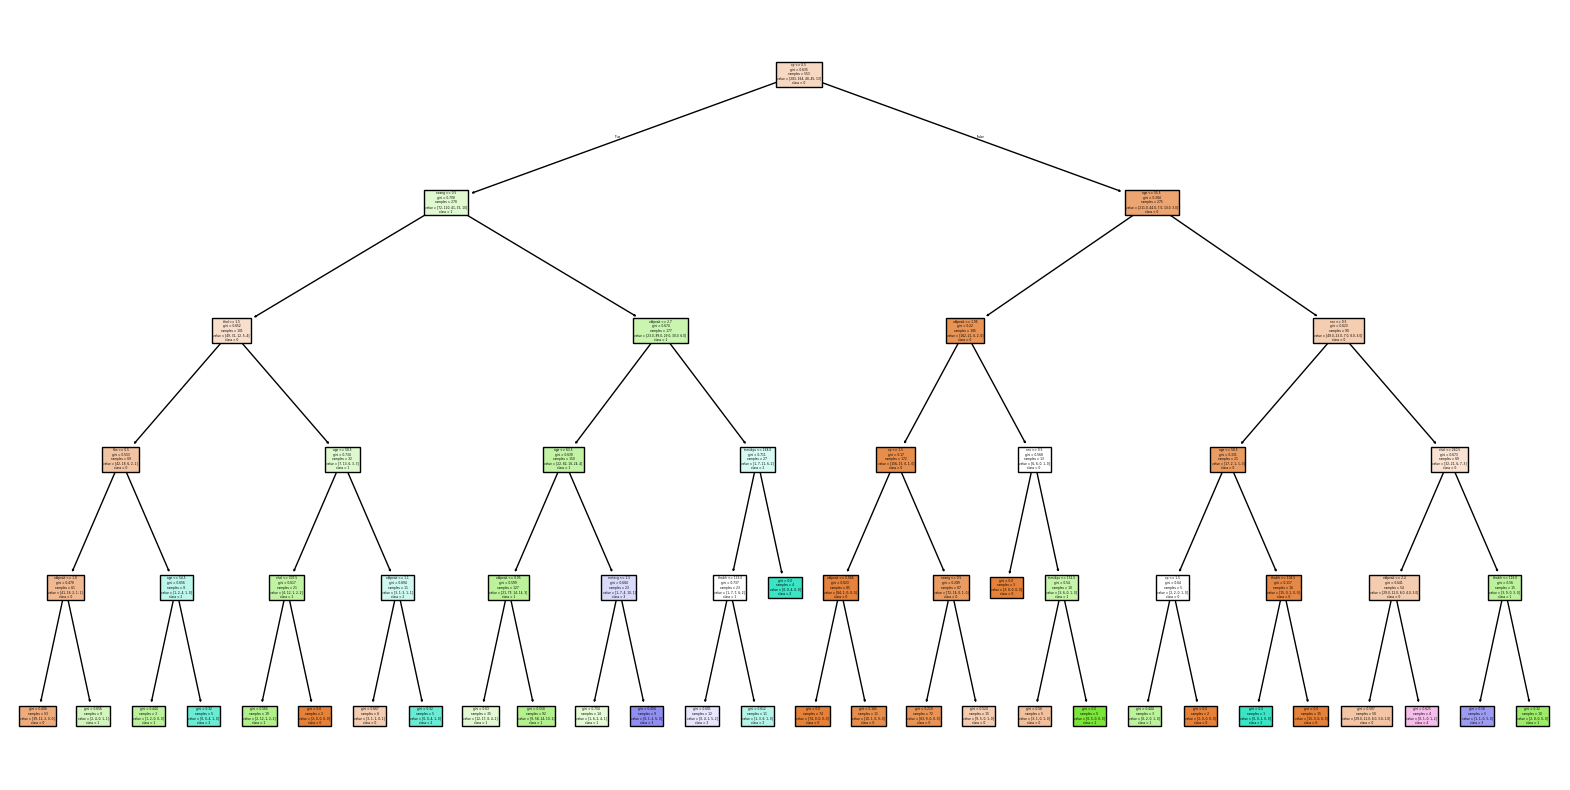

In [146]:
plt.figure(figsize=(20,10))
plot_tree(best_model, filled=True, feature_names=X.columns, class_names=[str(c) for c in best_model.classes_])
plt.show()

In [ ]:
# Feature Importance: Features appearing near the top are more important in decision-making, while those deeper in the tree contribute less.

# Node Colors: Colors indicate how "pure" or confident the model is about a certain prediction. Darker colors generally mean higher confidence or better separation between classes.

# Decision Flow: The hierarchical structure allows us to trace how the model makes predictions step-by-step.

In [148]:
feature_importances = best_model.feature_importances_
feature_names = X.columns
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': feature_importances})
importance_df = importance_df.sort_values('Importance', ascending=False)
importance_df

,Feature,Importance
2,cp,0.393736
0,age,0.146748
9,oldpeak,0.132822
8,exang,0.097654
7,thalch,0.046984
4,chol,0.041455
3,trestbps,0.035798
1,sex,0.034958
11,thal,0.031406
5,fbs,0.027782


In [150]:
#Interview questions:

# 1. Common Hyperparameters of Decision Tree Models and Their Impact:
# Decision tree models have several hyperparameters that influence their performance. Some of the key ones include:

# max_depth:
# -Limits the maximum depth of the tree.
# -Prevents overfitting by restricting how many levels the tree can grow.
# -A shallow tree may underfit (not capture enough detail), while a very deep tree might overfit (too complex and specific to the training data).

# min_samples_split:
# -The minimum number of samples required to split an internal node.
# -Higher values prevent the tree from growing too deep and help control overfitting.

# min_samples_leaf:
# -The minimum number of samples required to be at a leaf node.
# -Larger values create broader leaves, reducing overfitting but increasing bias.

# criterion:
# -Defines the function to measure the quality of a split.
# -Common options include Gini impurity ('gini') and Entropy ('entropy' for Information Gain).
# -This determines how the tree decides where to split.

# max_leaf_nodes:
# -Limits the number of leaf nodes in the tree.
# -Helps in controlling the model size and reducing overfitting.

# splitter:
# -Determines the splitting strategy.
# -'best' chooses the optimal split, while 'random' selects a random feature for splitting.

In [152]:
#2. Difference Between Label Encoding and One-Hot Encoding:
#Representation:
#- Label Encoding assigns a unique integer value to each category (e.g., 0, 1, 2).
#- One-Hot Encoding creates separate binary columns for each category with values 0 or 1.

#Order Bias:
#- Label Encoding can introduce a sense of order, which may lead to unintended bias.
#- One-Hot Encoding avoids order bias since categories are represented independently.

#Dimensionality:
#- Label Encoding keeps the data compact as it uses a single column.
#- One-Hot Encoding increases dimensionality, especially when the number of categories is high.

#Suitability:
#- Label Encoding is suitable for ordinal data (e.g., low, medium, high).
#- One-Hot Encoding is ideal for nominal data (e.g., red, blue, green), where categories have no order.

#Implementation:
#- Label Encoding is implemented using `LabelEncoder` from `sklearn`.
#- One-Hot Encoding can be done with `pd.get_dummies()` in pandas or `OneHotEncoder` in `sklearn`.

#Scalability:
#- Label Encoding works better for fewer categories, as it doesn't increase the number of columns.
#- One-Hot Encoding may become computationally expensive for datasets with many unique categories.
